# ORSY-Propensity-Modell (Klassifikation)

Ziel dieses Notebooks:

- Wir wollen vorhersagen, ob ein Kunde ein **ORSY-Kunde** ist (`flag_new_orsyshelf`).
- Typ des Problems: **Binäre Klassifikation** (0 = kein ORSY, 1 = ORSY).
- Wir verwenden:
  - einen **Decision Tree Classifier** als erstes Modell,
  - **Undersampling**, weil nur ca. 9 % der Kunden ORSY-Kunden sind,
  - den **F1-Score** als zentrale Kennzahl.

**Warum F1-Score?**

- Bei stark unausgeglichenen Klassen (hier ~9 % ORSY) ist Accuracy wenig hilfreich.
- F1 kombiniert **Precision** (Trefferqualität) und **Recall** (Trefferquote bei ORSY-Kunden).
- F1 ist hoch, wenn das Modell:
  - nicht zu viele „falsche ORSY-Treffer“ produziert (Precision) und
  - echte ORSY-Kunden nicht übersieht (Recall).

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils import resample

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("Imports erfolgreich geladen.")

Imports erfolgreich geladen.


In [2]:
# Pfad zur CSV – ggf. anpassen
data_path = "../data/dataset_wuerth.csv"

df = pd.read_csv(data_path)

# Zielvariable: ORSY (0/1)
df["orsy"] = (df["flag_new_orsyshelf"] > 0).astype(int)

print("Form des Datensatzes:", df.shape)
print("ORSY-Anteil gesamt: {:.2f}%".format(100 * df["orsy"].mean()))

df[["cust_id", "sales", "emp_count", "orsy"]].head()

Form des Datensatzes: (29493, 43)
ORSY-Anteil gesamt: 9.35%


,cust_id,sales,emp_count,orsy
0,40071,2445.11,1,0
1,66107,14070.62,10,1
2,33010,5893.92,8,0
3,96845,1823.72,4,0
4,64230,23654.08,8,1


## Feature-Auswahl

Wir starten mit einem sinnvollen Set an numerischen Merkmalen:

- **Kundengröße & Aktivität**
  - `emp_count` – Mitarbeiterzahl
  - `orders_count` – Anzahl Bestellungen
  - `diff_products_count` – Anzahl unterschiedlicher Produkte
  - `count_buyweeks`, `count_buymonths` – Kaufaktivität über die Zeit

- **Umsatz & Kanäle**
  - `sales` – Gesamtumsatz
  - `rev_salesrep`, `rev_branch_office`, `rev_ebusiness`,
    `rev_internal_staff`, `rev_others`

- **Digitales Verhalten**
  - `eshop_logins_count`
  - optionale Flags: `flag_app`, `flag_eproc`, `flag_eshop`, `flag_red`

In [3]:
# Basis-Features
features = [
    "emp_count",
    "orders_count",
    "sales",
    "rev_salesrep",
    "rev_branch_office",
    "rev_ebusiness",
    "rev_internal_staff",
    "rev_others",
    "eshop_logins_count",
    "count_buyweeks",
    "count_buymonths",
    "diff_products_count",
]

# optionale Flag-Features, falls vorhanden
flag_cols = ["flag_app", "flag_eproc", "flag_eshop", "flag_red"]
for c in flag_cols:
    if c in df.columns:
        features.append(c)

X = df[features].fillna(0)
y = df["orsy"]

print("Features:", features)
print("X-Form:", X.shape, " y-Form:", y.shape)

Features: ['emp_count', 'orders_count', 'sales', 'rev_salesrep', 'rev_branch_office', 'rev_ebusiness', 'rev_internal_staff', 'rev_others', 'eshop_logins_count', 'count_buyweeks', 'count_buymonths', 'diff_products_count', 'flag_app', 'flag_eproc', 'flag_eshop', 'flag_red']
X-Form: (29493, 16)  y-Form: (29493,)


## Undersampling der Mehrheitsklasse (Nicht-ORSY)

Nur etwa 9 % der Kunden sind ORSY-Kunden.  
Ohne Behandlung würde ein Modell einfach fast immer "kein ORSY" raten → hohe Accuracy, aber nutzlos.

Lösung hier: **Random Undersampling** der Nicht-ORSY-Kunden:

- Wir reduzieren die Anzahl der Nicht-ORSY-Kunden auf etwa das **3-fache** der ORSY-Kunden.
- Dadurch bekommt der Baum genug Beispiele für beide Klassen, ohne dass die Daten komplett künstlich werden.

In [4]:
# Mehrheit: Nicht-ORSY (0), Minderheit: ORSY (1)
df_major = df[df["orsy"] == 0]
df_minor = df[df["orsy"] == 1]

print("Originale Verteilung:")
print(df["orsy"].value_counts(normalize=True).rename("Anteil"))

# Zielgröße für Mehrheit (z.B. 3:1 Verhältnis)
target_major_n = min(len(df_major), len(df_minor) * 3)

df_major_down = resample(
    df_major,
    replace=False,
    n_samples=target_major_n,
    random_state=42
)

df_bal = pd.concat([df_major_down, df_minor]).sample(frac=1, random_state=42)

print("\nNeue Verteilung nach Undersampling:")
print(df_bal["orsy"].value_counts(normalize=True).rename("Anteil"))

X_bal = df_bal[features].fillna(0)
y_bal = df_bal["orsy"]

Originale Verteilung:
orsy
0    0.906452
1    0.093548
Name: Anteil, dtype: float64

Neue Verteilung nach Undersampling:
orsy
0    0.75
1    0.25
Name: Anteil, dtype: float64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

print("Train-Form:", X_train.shape, " Test-Form:", X_test.shape)
print("ORSY-Anteil Train:", y_train.mean().round(3))
print("ORSY-Anteil Test:", y_test.mean().round(3))

Train-Form: (8828, 16)  Test-Form: (2208, 16)
ORSY-Anteil Train: 0.25
ORSY-Anteil Test: 0.25


## Decision Tree Modell & F1-Score

Wir trainieren einen **DecisionTreeClassifier** mit:

- `max_depth=6` – begrenzte Tiefe → bessere Generalisierung, weniger Overfitting.
- `min_samples_leaf=50` – jedes Blatt enthält mindestens 50 Kunden.

Wir bewerten das Modell mit:

- **F1-Score für die Klasse ORSY (1)**  
  → kombiniert **Precision** (Trefferqualität) und **Recall** (Trefferquote bei ORSY-Kunden).
- zusätzlich: `classification_report` und Confusion Matrix.

In [6]:
tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=50,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

f1 = f1_score(y_test, y_pred, pos_label=1)
print("F1-Score (ORSY, Klasse=1):", round(f1, 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3, target_names=["kein ORSY", "ORSY"]))

F1-Score (ORSY, Klasse=1): 0.791

Classification Report:
              precision    recall  f1-score   support

   kein ORSY      0.924     0.943     0.933      1656
        ORSY      0.818     0.766     0.791       552

    accuracy                          0.899      2208
   macro avg      0.871     0.855     0.862      2208
weighted avg      0.897     0.899     0.898      2208



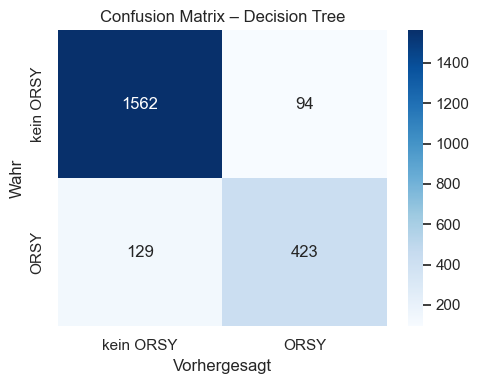

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["kein ORSY", "ORSY"],
    yticklabels=["kein ORSY", "ORSY"]
)
plt.xlabel("Vorhergesagt")
plt.ylabel("Wahr")
plt.title("Confusion Matrix – Decision Tree")
plt.tight_layout()
plt.show()

In [10]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": tree.feature_importances_
}).sort_values("Importance", ascending=False)

importance


,Feature,Importance
1,orders_count,0.795270
3,rev_salesrep,0.122051
10,count_buymonths,0.020505
11,diff_products_count,0.018857
15,flag_red,0.012450
5,rev_ebusiness,0.009568
0,emp_count,0.008957
4,rev_branch_office,0.006252
8,eshop_logins_count,0.003377
6,rev_internal_staff,0.002331


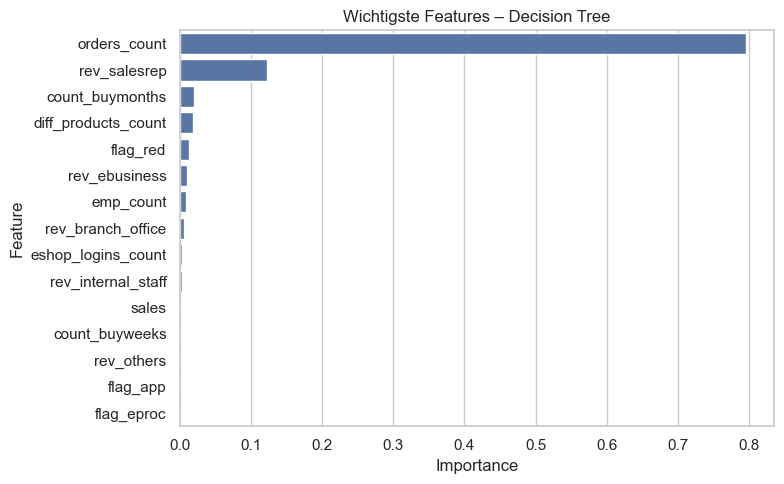

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(data=importance.head(15), x="Importance", y="Feature")
plt.title("Wichtigste Features – Decision Tree")
plt.tight_layout()
plt.show()

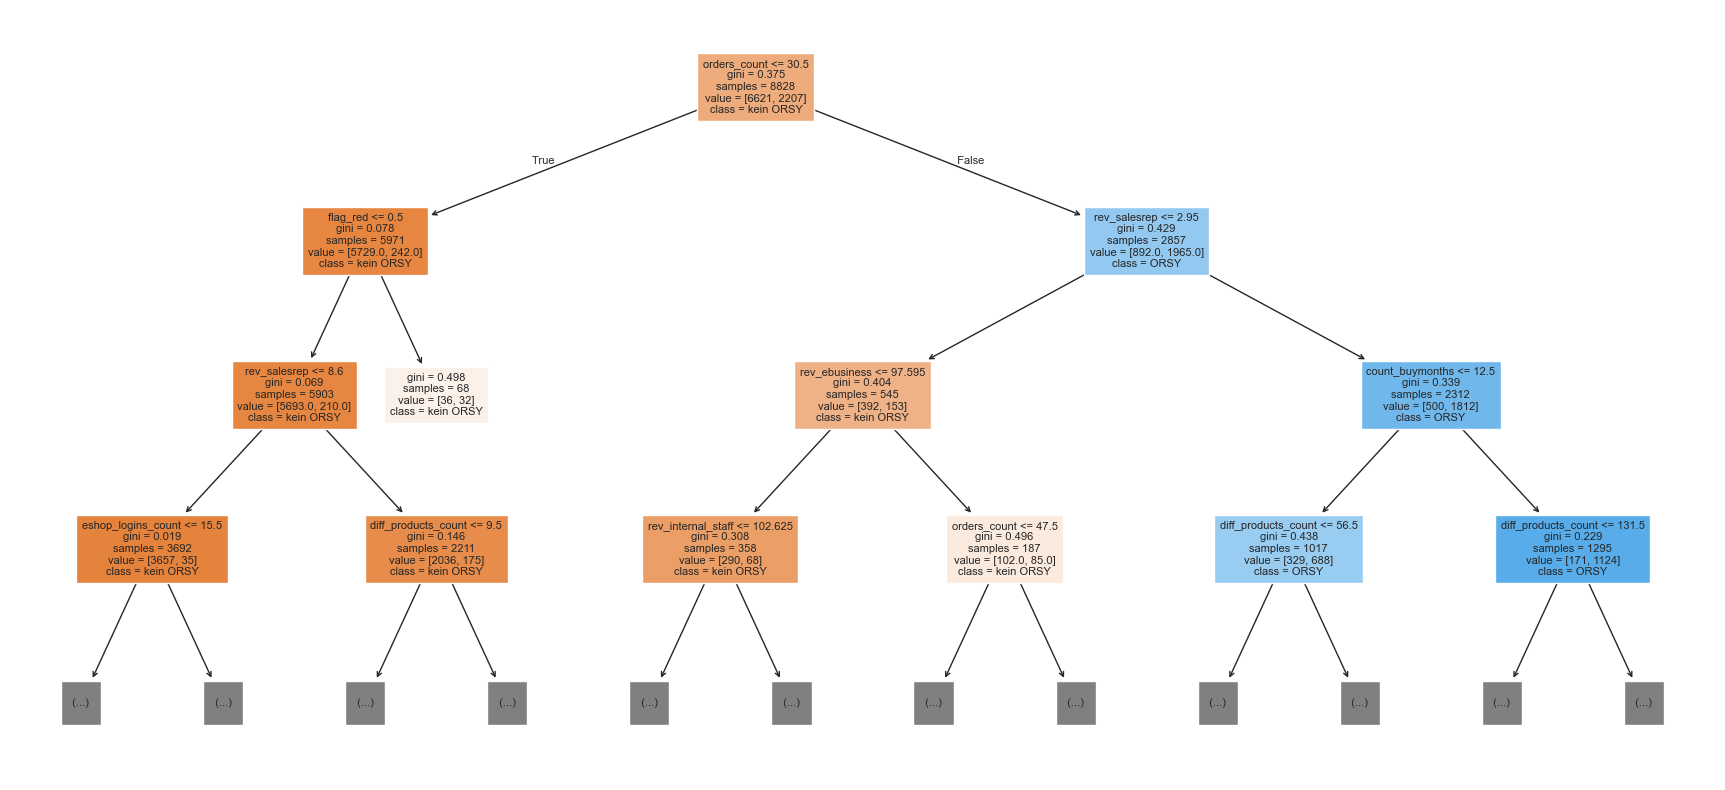

In [12]:
plt.figure(figsize=(22,10))
plot_tree(
    tree,
    feature_names=features,
    class_names=["kein ORSY", "ORSY"],
    filled=True,
    fontsize=8,
    max_depth=3   # nur die ersten Ebenen, sonst wird es unlesbar
)
plt.show()